In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [5]:
medical_df = pd.read_csv('insurance.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['figure.facecolor'] = '#000000'

In [7]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [8]:
fig = px.histogram(
    medical_df,
    x='age',
    nbins=47,
    title='Distribution of Age',
    marginal='box'
)
fig.update_layout(bargap=0.1)

In [9]:
px.violin(medical_df, x='children',y='charges')

In [10]:
smoker_values={'no':0,'yes':1}
smoker_numeric=medical_df.smoker.map(smoker_values)
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

Text(0.5, 1.0, 'Correlation Matrix')

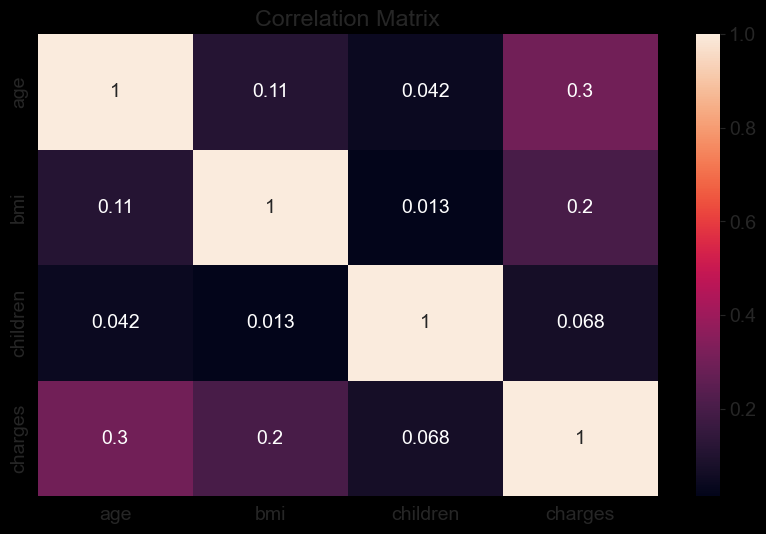

In [11]:
sns.heatmap(medical_df.drop(columns=['sex', 'smoker', 'region']).corr(), annot=True)
plt.title('Correlation Matrix')

<Axes: xlabel='age', ylabel='charges'>

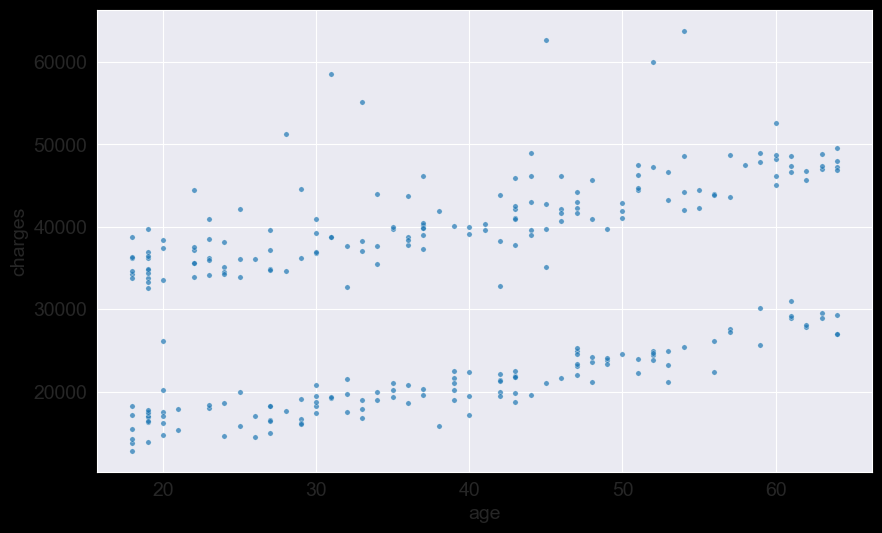

In [19]:
smoker_df = medical_df[medical_df.smoker == 'yes']
sns.scatterplot(data=smoker_df, x='age', y='charges', s=15, alpha=0.7)

In [20]:
def estimate_charges(a, w, b):
    return w*a+b

In [21]:
w = 50
b=100

In [22]:
ages=smoker_df.age
estimated_charges = estimate_charges(ages, w, b)
estimated_charges

0       1050
11      3200
14      1450
19      1600
23      1800
        ... 
1313    1050
1314    1600
1321    3200
1323    2200
1337    3150
Name: age, Length: 274, dtype: int64

In [23]:
smoker_df.charges

0       16884.92400
11      27808.72510
14      39611.75770
19      36837.46700
23      37701.87680
           ...     
1313    36397.57600
1314    18765.87545
1321    28101.33305
1323    43896.37630
1337    29141.36030
Name: charges, Length: 274, dtype: float64

Text(0, 0.5, 'Estimated Charges:')

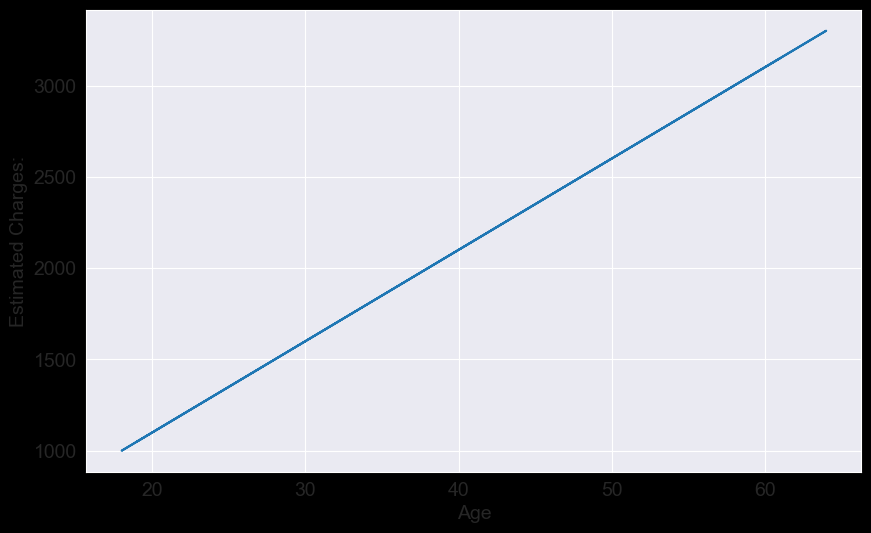

In [24]:
plt.plot(ages, estimated_charges)
plt.xlabel('Age')
plt.ylabel('Estimated Charges:')

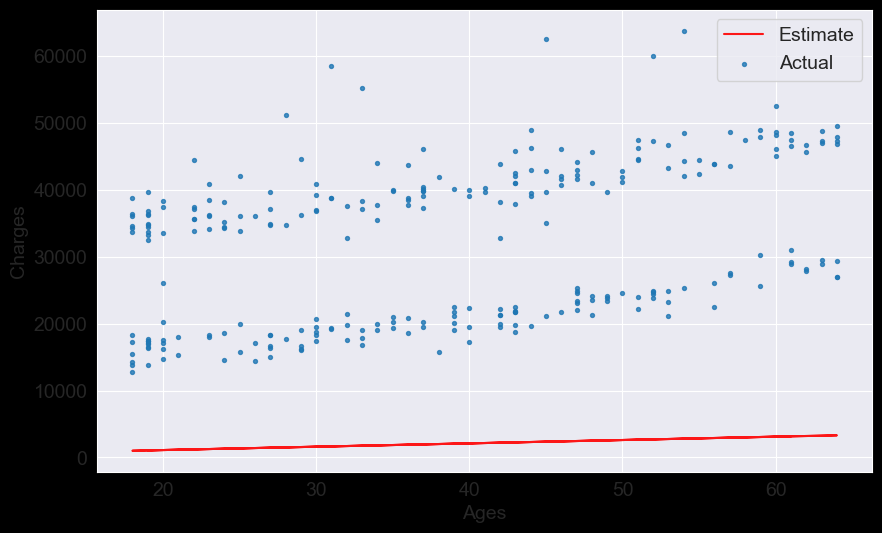

In [25]:
target = smoker_df.charges
plt.plot(ages, estimated_charges, alpha=0.9, c='r')
plt.scatter(ages, target, s=8, alpha=0.8)
plt.xlabel('Ages')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual'])

In [26]:
def try_parameters(w, b):
    ages = smoker_df.age
    target = smoker_df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, alpha=0.9, c='r')
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Ages')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])

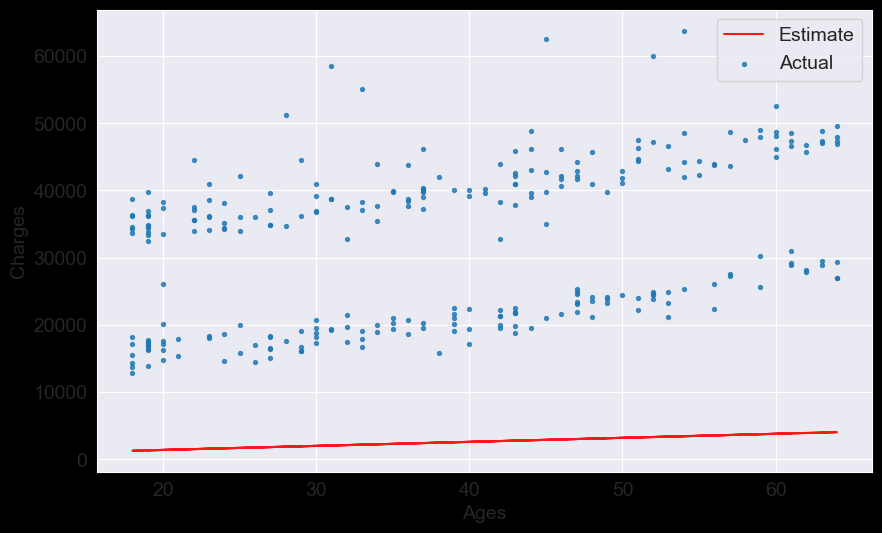

In [27]:
try_parameters(60, 200)

In [28]:
targets = smoker_df.charges
targets

0       16884.92400
11      27808.72510
14      39611.75770
19      36837.46700
23      37701.87680
           ...     
1313    36397.57600
1314    18765.87545
1321    28101.33305
1323    43896.37630
1337    29141.36030
Name: charges, Length: 274, dtype: float64

In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
inputs = smoker_df[['age']]
print(f'inputs.shape {inputs.shape}')
print(f'targets.shape {targets.shape}')

inputs.shape (274, 1)
targets.shape (274,)


In [30]:
model.fit(inputs, targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [32]:
predictions = model.predict(inputs)

In [33]:
# w
model.coef_

array([305.23760211])

In [ ]:
# b
model.intercept_

np.float64(20294.12812691597)

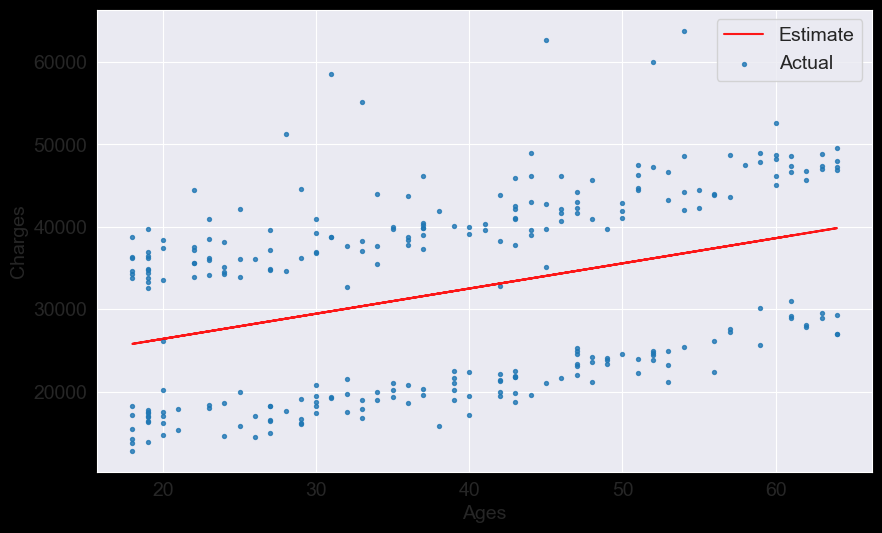

In [40]:
try_parameters(model.coef_, model.intercept_)

In [43]:
from sklearn.linear_model import SGDRegressor
model2 = SGDRegressor()
model2.fit(inputs, targets)
model2.predict(inputs)

array([-1.46202689e+09,  8.58218350e+09,  4.06663416e+08,  1.10742228e+09,
        2.04176743e+09,  1.34100857e+09, -7.61268024e+08,  6.40249704e+08,
        2.27535372e+09,  8.11501092e+09,  2.50894001e+09,  5.31197547e+09,
        2.50894001e+09,  7.64783835e+09, -1.69561318e+09,  6.47990691e+09,
       -1.22844060e+09,  6.40249704e+08,  4.06663416e+08, -7.61268024e+08,
        2.74252630e+09,  4.61121660e+09,  7.41425206e+09,  7.88142463e+09,
        9.04935608e+09,  7.18066577e+09,  2.97611259e+09,  8.34859721e+09,
       -1.22844060e+09,  8.81576979e+09,  8.73835992e+08,  4.37763031e+09,
       -1.46202689e+09,  1.57459486e+09,  2.04176743e+09,  1.10742228e+09,
        4.84480289e+09,  3.91045774e+09,  5.31197547e+09, -1.69561318e+09,
        1.10742228e+09,  3.91045774e+09, -1.69561318e+09,  8.81576979e+09,
        2.50894001e+09,  4.06663416e+08,  2.27535372e+09, -1.46202689e+09,
        3.91045774e+09,  3.44328516e+09, -1.46202689e+09, -5.27681736e+08,
        8.81576979e+09, -

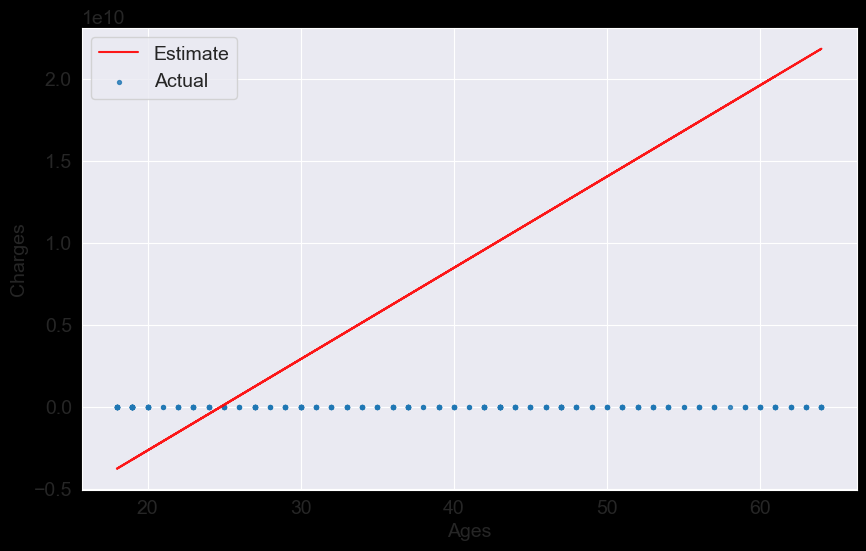

In [42]:
try_parameters(model2.coef_,model2.intercept_)

In [44]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [45]:
targets = smoker_df['charges']
predicted = estimate_charges(smoker_df.age, w, b)

In [46]:
rmse(targets, predicted)

np.float64(32074.58722734571)

In [47]:
estimated_charges

0       1050
11      3200
14      1450
19      1600
23      1800
        ... 
1313    1050
1314    1600
1321    3200
1323    2200
1337    3150
Name: age, Length: 274, dtype: int64

In [48]:
def try_parameters(w,b):
    ages = smoker_df.age
    target = smoker_df.charges
    predcitions = estimate_charges(ages, w, b)

    plt.plot(ages, predcitions, 'r', alpha=0.9)
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Ages')
    plt.ylabel('Charges')
    plt.legend(['Prediction', 'Actual'])

    loss = rmse(target, predcitions)
    print(f'mse={loss}')

mse=4486153295.0508175


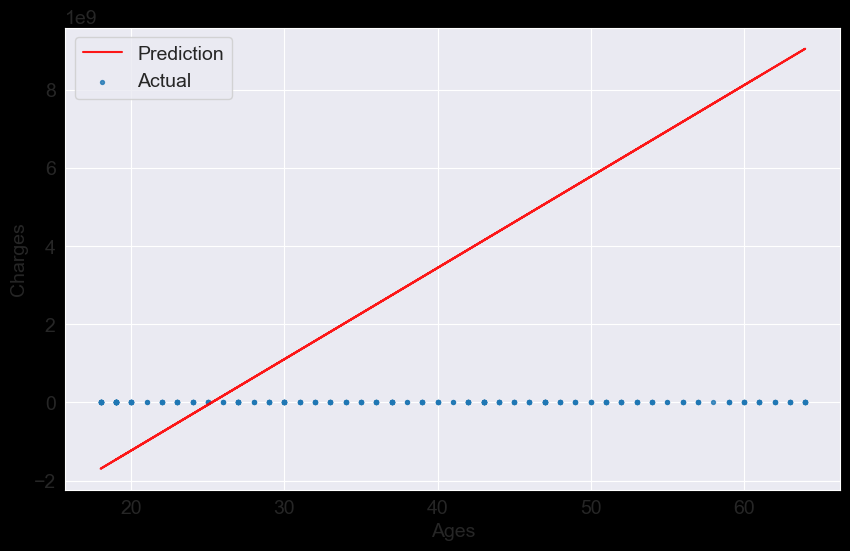

In [49]:
try_parameters(model2.coef_,model2.intercept_)

mse=10711.00334810241


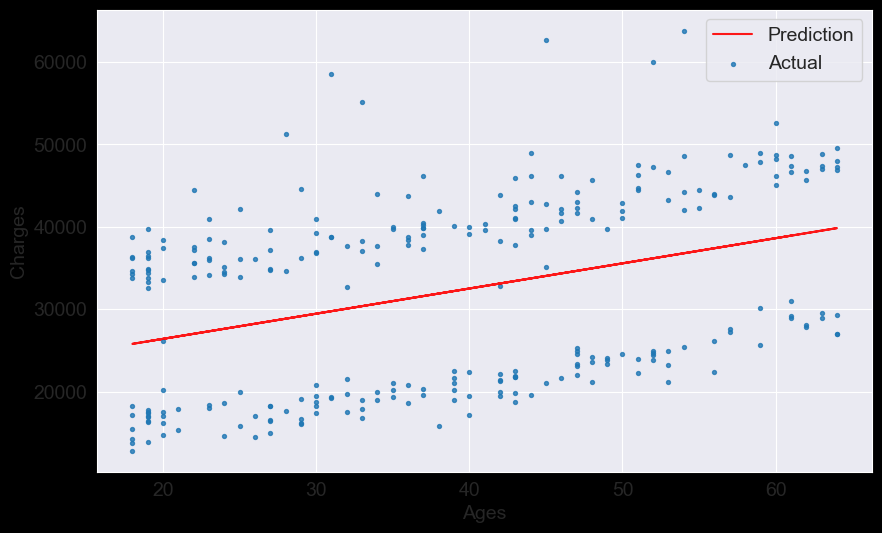

In [50]:
try_parameters(model.coef_,model.intercept_)